In [1]:
# CELL 1 — Imports, Reproducibility, Setup
import sys
import os
import numpy as np
import random
import tensorflow as tf

# Force CPU only
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Reproducibility settings applied (CPU mode).")

# General imports
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import re
from math import atan2, asin
from scipy.signal import butter, filtfilt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from tensorflow import keras
from tensorflow.keras import layers

# Dataset paths
RAW_ROOT = Path("wide_data")
CLEAN_ROOT = Path("cleaned_data_lstm")
CLEAN_ROOT.mkdir(exist_ok=True)

# Quick sanity checks
print("Local dataset paths set.")
print("RAW_ROOT  =", RAW_ROOT.resolve())
print("CLEAN_ROOT=", CLEAN_ROOT.resolve())

if not RAW_ROOT.exists():
    raise FileNotFoundError(
        f"wide_data folder not found at: {RAW_ROOT.resolve()}\n"
        "Put wide_data in the same directory as the notebook, or adjust RAW_ROOT."
    )

print("Dataset ready (local).")

Reproducibility settings applied (CPU mode).
Local dataset paths set.
RAW_ROOT  = D:\Documents\GitHub\GP-DL-MODEL\FINAL MODELS\RANDOM SPLITS WITH PREPROCESSING\wide_data
CLEAN_ROOT= D:\Documents\GitHub\GP-DL-MODEL\FINAL MODELS\RANDOM SPLITS WITH PREPROCESSING\cleaned_data_lstm
Dataset ready (local).


In [2]:
# CELL 2 — Sensor Feature Definitions + Quaternion Math
SENSORS = ["L5", "T4", "C7", "T12"]

ACC_FEATURES  = ["Acceleration X(g)", "Acceleration Y(g)", "Acceleration Z(g)"]
GYRO_FEATURES = ["Angular velocity X(°/s)", "Angular velocity Y(°/s)", "Angular velocity Z(°/s)"]
QUAT_FEATURES = ["Quaternions 0()", "Quaternions 1()", "Quaternions 2()", "Quaternions 3()"]

MAG_WEAK_PREFIX = "Magnetic field"

POSTURES = sorted([p.name for p in RAW_ROOT.iterdir() if p.is_dir()])
LABEL_TO_ID = {p: i for i, p in enumerate(POSTURES)}

print("Detected Postures:", POSTURES)
print("Label Map:", LABEL_TO_ID)


# -------------------------
# Magnetometer detection
# -------------------------
def detect_mag_cols(df, sensor):
    cols = df.columns
    out = []

    for axis in ["x", "y", "z"]:
        matches = [
            c for c in cols
            if c.lower().startswith(sensor.lower() + "_magnetic field")
            and axis in c.lower()
        ]
        if not matches:
            raise KeyError(f" Missing magnetometer axis={axis} for sensor={sensor}\n{list(cols)}")

        out.append(matches[0])

    return out


# -------------------------
# Quaternion helpers
# -------------------------
def quat_reorder_to_wxyz(qx, qy, qz, qw):
    return np.array([qw, qx, qy, qz], dtype=np.float32)

def quat_conjugate(q):
    w,x,y,z = q
    return np.array([w, -x, -y, -z], dtype=np.float32)

def quat_multiply(q1, q2):
    w1,x1,y1,z1 = q1
    w2,x2,y2,z2 = q2
    return np.array([
        w1*w2 - x1*x2 - y1*y2 - z1*z2,
        w1*x2 + x1*w2 + y1*z2 - z1*y2,
        w1*y2 - x1*z2 + y1*w2 + z1*x2,
        w1*z2 + x1*y2 - y1*x2 + z1*w2
    ], dtype=np.float32)

def rotate_vector_by_quaternion(q, v):
    vq = np.array([0, v[0], v[1], v[2]], dtype=np.float32)
    return quat_multiply(quat_multiply(q, vq), quat_conjugate(q))[1:]

def quaternion_to_euler(q):
    w,x,y,z = q
    yaw   = atan2(2*(w*z + x*y), 1 - 2*(y*y + z*z))
    pitch = asin(np.clip(2*(w*y - z*x), -1, 1))
    roll  = atan2(2*(w*x + y*z), 1 - 2*(x*x + y*y))
    return yaw, pitch, roll

Detected Postures: ['1', '2', '3', '4', '5', '6']
Label Map: {'1': 0, '2': 1, '3': 2, '4': 3, '5': 4, '6': 5}


In [3]:
# CELL 3 — Preprocessing Filters
def hampel_filter(x, window_size=5, n_sigmas=3):
    x = x.copy()
    y = x.copy()
    N = len(x)
    k = window_size

    for i in range(k, N-k):
        window = x[i-k:i+k+1]
        median = np.nanmedian(window)
        mad = np.nanmedian(np.abs(window - median))

        if mad < 1e-6:
            continue

        if abs(x[i] - median) > n_sigmas * 1.4826 * mad:
            y[i] = median

    return y

def butter_lowpass_filter(x, cutoff=3.0, fs=50, order=2):
    b,a = butter(order, cutoff/(0.5*fs), btype="low")
    try:
        return filtfilt(b,a,x,axis=0)
    except:
        return x

def remove_bias(x):
    return x - np.nanmean(x, axis=0)

In [4]:
# CELL 4 — Full Preprocessing Pipeline
def preprocess_single_file(raw_path):
    """
    Preprocess a single raw CSV file and return the processed array (ALL FEATURES).
    Does NOT write to disk.
    """
    df = pd.read_csv(raw_path)

    # Keep relevant columns only
    keep = []
    for col in df.columns:
        for s in SENSORS:
            if col.startswith(f"{s}_Acceleration"):     keep.append(col)
            elif col.startswith(f"{s}_Angular velocity"): keep.append(col)
            elif col.startswith(f"{s}_Quaternions"):     keep.append(col)
            elif col.startswith(f"{s}_Magnetic field"):  keep.append(col)

    df = df[keep].copy().apply(pd.to_numeric, errors="coerce")

    df.replace([np.inf,-np.inf], np.nan, inplace=True)
    df.interpolate(limit_direction="both", inplace=True)
    df.ffill(inplace=True)
    df.bfill(inplace=True)

    blocks = []

    for sensor in SENSORS:

        acc = df[[f"{sensor}_{f}" for f in ACC_FEATURES]].values
        gyr = df[[f"{sensor}_{f}" for f in GYRO_FEATURES]].values
        quat_raw = df[[f"{sensor}_{f}" for f in QUAT_FEATURES]].values
        mag_cols = detect_mag_cols(df, sensor)
        mag = df[mag_cols].values

        # Quaternion normalization
        quats = []
        for (qx,qy,qz,qw) in quat_raw:
            q = quat_reorder_to_wxyz(qx,qy,qz,qw)
            q = q / np.linalg.norm(q)
            quats.append(q)
        quats = np.array(quats)

        # Remove bias
        acc = remove_bias(acc)
        gyr = remove_bias(gyr)
        mag = remove_bias(mag)

        # Hampel filtering
        for i in range(acc.shape[1]): acc[:,i] = hampel_filter(acc[:,i])
        for i in range(gyr.shape[1]): gyr[:,i] = hampel_filter(gyr[:,i])
        for i in range(mag.shape[1]): mag[:,i] = hampel_filter(mag[:,i])

        # Low-pass filter
        acc = butter_lowpass_filter(acc)
        gyr = butter_lowpass_filter(gyr)
        mag = butter_lowpass_filter(mag)

        # Orientation alignment + Euler
        A,G,M,E = [],[],[],[]

        for t in range(len(df)):
            q = quats[t]
            A.append(rotate_vector_by_quaternion(q, acc[t]))
            G.append(rotate_vector_by_quaternion(q, gyr[t]))
            M.append(rotate_vector_by_quaternion(q, mag[t]))
            E.append(quaternion_to_euler(q))

        A = np.array(A); G = np.array(G); M = np.array(M); E = np.array(E)

        A_mag = np.linalg.norm(A,axis=1,keepdims=True)
        G_mag = np.linalg.norm(G,axis=1,keepdims=True)
        M_mag = np.linalg.norm(M,axis=1,keepdims=True)

        block = np.concatenate([A,G,M,A_mag,G_mag,M_mag,E], axis=1)
        blocks.append(block)

    X_out = np.concatenate(blocks, axis=1)

    return X_out

In [5]:
# CELL 5 — Load and Preprocess All Data
print("\n===== PREPROCESSING ALL FILES =====\n")

SUBJECT_RE = re.compile(r"Sub_(\d+)_Trial_(\d+)\.csv")

rows = []

for posture_dir in RAW_ROOT.iterdir():
    if not posture_dir.is_dir():
        continue

    files = list(posture_dir.glob("*.csv"))
    print(f"Processing posture: {posture_dir.name} ({len(files)} files)")

    for raw_file in files:
        # Preprocess in-memory (no disk I/O for cleaned files)
        X_processed = preprocess_single_file(raw_file)
        
        # Extract subject and trial info
        m = SUBJECT_RE.search(raw_file.name)
        if m:
            rows.append({
                "data": X_processed,
                "posture": posture_dir.name,
                "label": LABEL_TO_ID[posture_dir.name],
                "subject": int(m.group(1)),
                "trial": int(m.group(2)),
                "filename": raw_file.name
            })

df_items = pd.DataFrame(rows)

print(f"\nTotal processed files: {len(df_items)}")
print(f"Unique subjects: {df_items['subject'].nunique()}")
print(f"Feature dimension: {df_items['data'].iloc[0].shape[1]}")


===== PREPROCESSING ALL FILES =====

Processing posture: 1 (138 files)
Processing posture: 2 (138 files)
Processing posture: 3 (138 files)
Processing posture: 4 (138 files)
Processing posture: 5 (138 files)
Processing posture: 6 (138 files)

Total processed files: 828
Unique subjects: 46
Feature dimension: 60


In [6]:
# CELL 6 — Windowing
FS = 50
WIN_LEN = 200
STRIDE = 100

print(f"\nWindow length = {WIN_LEN} frames ({WIN_LEN/FS:.2f} sec)")
print(f"Stride = {STRIDE} frames")

def make_windows(X):
    """
    Convert a full sequence (T,F) into windows (num_windows, WIN_LEN, F)
    with overlap.
    """
    T, F = X.shape

    # If trial is shorter than window, pad with zeros
    if T < WIN_LEN:
        w = np.zeros((WIN_LEN, F))
        w[:T] = X
        return w[None,:,:]

    windows = []
    for i in range(0, T - WIN_LEN + 1, STRIDE):
        windows.append(X[i:i+WIN_LEN])

    return np.array(windows)


Window length = 200 frames (4.00 sec)
Stride = 100 frames


In [7]:
# CELL 7 — Create Window Dataset (ACC + EULER ONLY)
X_all = []
y_all = []
subj_all = []
trial_all = []

window_counter = 0

def select_acc_euler(X):
    """
    Input: (T, 60)
    Output: (T, 24)  -> 4 sensors × (acc(3) + euler(3))
    """

    selected = []

    for i in range(4):

        start = i * 15

        acc   = X[:, start + 0 : start + 3]
        euler = X[:, start + 12 : start + 15]

        selected.append(acc)
        selected.append(euler)

    return np.concatenate(selected, axis=1)


for _, row in df_items.iterrows():

    X = row["data"]  # Use preprocessed data from memory

    # keep only acc + euler
    X = select_acc_euler(X)

    windows = make_windows(X)

    for w in windows:

        X_all.append(w)
        y_all.append(row["label"])
        subj_all.append(row["subject"])
        trial_all.append(row["trial"])

    window_counter += len(windows)

X_all = np.array(X_all)
y_all = np.array(y_all)
subj_all = np.array(subj_all)
trial_all = np.array(trial_all)

print("\n===== DATASET SUMMARY =====")
print("Total windows:", window_counter)
print("X shape:", X_all.shape)
print("Features per timestep:", X_all.shape[2])


===== DATASET SUMMARY =====
Total windows: 11549
X shape: (11549, 200, 24)
Features per timestep: 24


In [8]:
# CELL 8 — Subject Split
EXCLUDED_SUBJECTS = [29]

subjects = sorted(
    s for s in np.unique(subj_all)
    if s not in EXCLUDED_SUBJECTS
)

print("Remaining subjects:", subjects)

train_subj, temp_subj = train_test_split(
    subjects,
    test_size=0.30,
    random_state=SEED
)

val_subj, test_subj = train_test_split(
    temp_subj,
    test_size=0.50,
    random_state=SEED
)

print("Train subjects:", train_subj)
print("Val subjects:", val_subj)
print("Test subjects:", test_subj)

# =========================================
# CREATE MASKS
# =========================================

train_mask = np.isin(subj_all, train_subj)
val_mask   = np.isin(subj_all, val_subj)
test_mask  = np.isin(subj_all, test_subj)

# =========================================
# SPLIT DATA
# =========================================

X_train = X_all[train_mask]
X_val   = X_all[val_mask]
X_test  = X_all[test_mask]

y_train = y_all[train_mask]
y_val   = y_all[val_mask]
y_test  = y_all[test_mask]

print("\nDataset shapes")
print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)

# =========================================
# ONE HOT ENCODE LABELS
# =========================================

y_train = keras.utils.to_categorical(y_train, num_classes=len(POSTURES))
y_val   = keras.utils.to_categorical(y_val,   num_classes=len(POSTURES))
y_test  = keras.utils.to_categorical(y_test,  num_classes=len(POSTURES))

print("\nLabel shapes")
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

Remaining subjects: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46)]
Train subjects: [np.int64(18), np.int64(14), np.int64(44), np.int64(16), np.int64(10), np.int64(17), np.int64(39), np.int64(33), np.int64(28), np.int64(1), np.int64(32), np.int64(31), np.int64(6), np.int64(12), np.int64(35), np.int64(2), np.int64(42), np.int64(22), np.int64(3), np.int64(36), np.int64(24), np.int64(38), np.int64(11), np.int64(23), np.int64(

In [9]:
# CELL 9 — Per Sensor Normalization
SENSOR_SLICES = [
    slice(0,6),
    slice(6,12),
    slice(12,18),
    slice(18,24)
]

def compute_sensor_norm(X):

    means = []
    stds  = []

    for s in SENSOR_SLICES:

        flat = X[:,:,s].reshape(-1,6)

        mean = flat.mean(axis=0, keepdims=True)
        std  = flat.std(axis=0, keepdims=True) + 1e-8

        means.append(mean)
        stds.append(std)

    return means, stds


def apply_sensor_norm(X, means, stds):

    Xn = X.copy()

    for s, mean, std in zip(SENSOR_SLICES, means, stds):

        Xn[:,:,s] = (X[:,:,s] - mean) / std

    return Xn


means, stds = compute_sensor_norm(X_train)

X_train = apply_sensor_norm(X_train, means, stds)
X_val   = apply_sensor_norm(X_val, means, stds)
X_test  = apply_sensor_norm(X_test, means, stds)

print("Normalization applied")
print("Train shape:", X_train.shape)
print("Val shape:", X_val.shape)
print("Test shape:", X_test.shape)

Normalization applied
Train shape: (7774, 200, 24)
Val shape: (1761, 200, 24)
Test shape: (1762, 200, 24)


In [39]:
# CELL 10 — Save Normalization Stats
norm_path = "norm_stats.npz"
np.savez(
    norm_path,
    **{f"mean_{i}": m for i, m in enumerate(means)},
    **{f"std_{i}": s for i, s in enumerate(stds)}
 )
print("Saved normalization stats to:", norm_path)

Saved normalization stats to: norm_stats.npz


In [10]:
# CELL 10 — SensorDropout Layer
class SensorDropout(layers.Layer):

    def __init__(self, drop_prob=0.2):
        super().__init__()
        self.drop_prob = drop_prob

    def call(self, x, training=None):

        if not training:
            return x

        batch = tf.shape(x)[0]

        mask = tf.ones((batch, 4, 1), dtype=x.dtype)

        drop = tf.cast(
            tf.random.uniform((batch, 4, 1)) > self.drop_prob,
            x.dtype
        )

        mask = mask * drop

        mask = tf.repeat(mask, repeats=6, axis=2)

        mask = tf.reshape(mask, (batch, 1, 24))

        return x * mask

In [11]:
# CELL 11 — Model with Sensor Attention + Global Avg Pool
def build_model(input_shape):

    inp = keras.Input(shape=input_shape)

    print("Model input:", input_shape)

    x = inp   

    # ---------------------------------
    # Split sensors
    # ---------------------------------

    L5  = layers.Lambda(lambda x: x[:,:,0:6])(x)
    T4  = layers.Lambda(lambda x: x[:,:,6:12])(x)
    C7  = layers.Lambda(lambda x: x[:,:,12:18])(x)
    T12 = layers.Lambda(lambda x: x[:,:,18:24])(x)

    print("Sensor feature size:", 6)

    # ---------------------------------
    # Sensor CNN block
    # ---------------------------------

    def sensor_block(x):

        x = layers.Conv1D(
            filters=32,
            kernel_size=5,
            padding="same",
            activation="relu"
        )(x)

        x = layers.BatchNormalization()(x)

        x = layers.Conv1D(
            filters=32,
            kernel_size=3,
            padding="same",
            activation="relu"
        )(x)

        x = layers.BatchNormalization()(x)

        # Feature attention
        attention = layers.Dense(x.shape[-1], activation="tanh")(x)
        attention = layers.Softmax(axis=-1)(attention)

        x = layers.Multiply()([x, attention])

        return x

    L5  = sensor_block(L5)
    T4  = sensor_block(T4)
    C7  = sensor_block(C7)
    T12 = sensor_block(T12)

    # ---------------------------------
    # Stack sensors
    # ---------------------------------

    sensors = layers.Lambda(
        lambda x: tf.stack(x, axis=2)
    )([L5, T4, C7, T12])

    # ---------------------------------
    # Sensor attention
    # ---------------------------------

    attention = layers.Dense(1, activation="tanh")(sensors)
    attention = layers.Softmax(axis=2)(attention)

    sensors = layers.Multiply()([sensors, attention])

    fused = layers.Lambda(
        lambda x: tf.reduce_sum(x, axis=2)
    )(sensors)

    # ---------------------------------
    # TEMPORAL POOLING
    # ---------------------------------

    x = layers.GlobalAveragePooling1D()(fused)

    # ---------------------------------
    # CLASSIFIER
    # ---------------------------------

    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.4)(x)

    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.3)(x)

    out = layers.Dense(
        len(POSTURES),
        activation="softmax"
    )(x)

    model = keras.Model(inp, out)

    model.compile(
        optimizer=keras.optimizers.Adam(1e-4),
        loss=tf.keras.losses.CategoricalCrossentropy(
            label_smoothing=0.05
        ),
        metrics=["accuracy"]
    )

    model.summary()

    return model

In [12]:
# CELL 12 — Learning Rate Scheduler
lr_scheduler = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

In [21]:
# CELL 13 — Build and Train Model
model = build_model(X_train.shape[1:])

early = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

checkpoint = keras.callbacks.ModelCheckpoint(
    filepath="model_weights_best.weights.h5",
    monitor="val_loss",
    save_best_only=True,
    save_weights_only=True,
    verbose=1
)

hist = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=60,
    batch_size=32,
    callbacks=[early, lr_scheduler, checkpoint],
    verbose=1
)

Model input: (200, 24)
Sensor feature size: 6


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 200, 24)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_12 (Lambda)  │ (None, 200, 6)    │          0 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_13 (Lambda)  │ (None, 200, 6)    │          0 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_14 (Lambda)  │ (None, 200, 6)    │          0 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_15 (Lambda)  │ (None, 200, 6)    │          0 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_16 (Conv1D)  │ (None, 200, 32)   │        992 │ lambda_12[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_18 (Conv1D)  │ (None, 200, 32)   │        992 │ lambda_13[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_20 (Conv1D)  │ (None, 200, 32)   │        992 │ lambda_14[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_22 (Conv1D)  │ (None, 200, 32)   │        992 │ lambda_15[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_16[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_18[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_20[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_22[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_17 (Conv1D)  │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_19 (Conv1D)  │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_21 (Conv1D)  │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_23 (Conv1D)  │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_17[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_19[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_21[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_23[0][0] 

 Total params: 34,535 (134.90 KB)

 Trainable params: 34,023 (132.90 KB)

 Non-trainable params: 512 (2.00 KB)

Epoch 1/60
243/243 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.2704 - loss: 1.7787
Epoch 1: val_loss improved from None to 1.70412, saving model to model_weights_best.weights.h5

Epoch 1: finished saving model to model_weights_best.weights.h5
243/243 ━━━━━━━━━━━━━━━━━━━━ 14s 27ms/step - accuracy: 0.3458 - loss: 1.7578 - val_accuracy: 0.4980 - val_loss: 1.7041 - learning_rate: 1.0000e-04
Epoch 2/60
241/243 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5119 - loss: 1.6111
Epoch 2: val_loss improved from 1.70412 to 1.39075, saving model to model_weights_best.weights.h5

Epoch 2: finished saving model to model_weights_best.weights.h5
243/243 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.5453 - loss: 1.5414 - val_accuracy: 0.6485 - val_loss: 1.3908 - learning_rate: 1.0000e-04
Epoch 3/60
242/243 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6774 - loss: 1.3184
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.

Epoch 3: val_loss improved from 1.39075 to 1.0

In [22]:
# CELL 14 — Save Full Model + Quick Inference Example
model_path = "random_splits_model.keras"
model.save(model_path)
print("Saved full model to:", model_path)

# Example inference on one sample window
sample = X_test[0:1]  # shape: (1, WIN_LEN, 24)
pred_probs = model.predict(sample, verbose=0)
pred_label = int(np.argmax(pred_probs, axis=1)[0])
print("Predicted label id:", pred_label)
print("Predicted posture:", POSTURES[pred_label])

Saved full model to: random_splits_model.keras
Predicted label id: 0
Predicted posture: 1


In [24]:
# CELL 15 — Rebuild Model + Load Weights + Predict
loaded_model = build_model(X_train.shape[1:])
loaded_model.load_weights("model_weights_best.weights.h5")
print("Loaded weights from model_weights_best.weights.h5")

# Example inference on one sample window
sample = X_test[0:1]  # shape: (1, WIN_LEN, 24)
pred_probs = loaded_model.predict(sample, verbose=0)
pred_label = int(np.argmax(pred_probs, axis=1)[0])
print("Predicted label id:", pred_label)
print("Predicted posture:", POSTURES[pred_label])

Model input: (200, 24)
Sensor feature size: 6


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 200, 24)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_18 (Lambda)  │ (None, 200, 6)    │          0 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_19 (Lambda)  │ (None, 200, 6)    │          0 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_20 (Lambda)  │ (None, 200, 6)    │          0 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_21 (Lambda)  │ (None, 200, 6)    │          0 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_24 (Conv1D)  │ (None, 200, 32)   │        992 │ lambda_18[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_26 (Conv1D)  │ (None, 200, 32)   │        992 │ lambda_19[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_28 (Conv1D)  │ (None, 200, 32)   │        992 │ lambda_20[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_30 (Conv1D)  │ (None, 200, 32)   │        992 │ lambda_21[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_24[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_26[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_28[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_30[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_25 (Conv1D)  │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_27 (Conv1D)  │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_29 (Conv1D)  │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_31 (Conv1D)  │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_25[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_27[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_29[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_31[0][0] 

 Total params: 34,535 (134.90 KB)

 Trainable params: 34,023 (132.90 KB)

 Non-trainable params: 512 (2.00 KB)

C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\saving\saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 98 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Loaded weights from model_weights_best.weights.h5
Predicted label id: 0
Predicted posture: 1


In [38]:
# CELL 16 — Predict From Your Own CSV (wide_data)
from pathlib import Path

# Pick a file from wide_data/2 (change as needed)
files = sorted(Path("wide_data/5").glob("*.csv"))
subject=17
user_file = files[subject-1]  # 4th file
print("Using file:", user_file)

# Preprocess -> select acc+euler -> window
X_full = preprocess_single_file(user_file)
X_full = select_acc_euler(X_full)
X_windows = make_windows(X_full)

# Apply the same normalization from training
X_windows = apply_sensor_norm(X_windows, means, stds)

# Predict per-window, then aggregate to a trial label
probs = loaded_model.predict(X_windows, verbose=0)
summed = np.sum(np.log(probs + 1e-8), axis=0)
pred_label = int(np.argmax(summed))
print("Predicted label id:", pred_label)
print("Predicted posture:", POSTURES[pred_label])

Using file: wide_data\5\Sub_06_Trial_04.csv
Predicted label id: 4
Predicted posture: 5


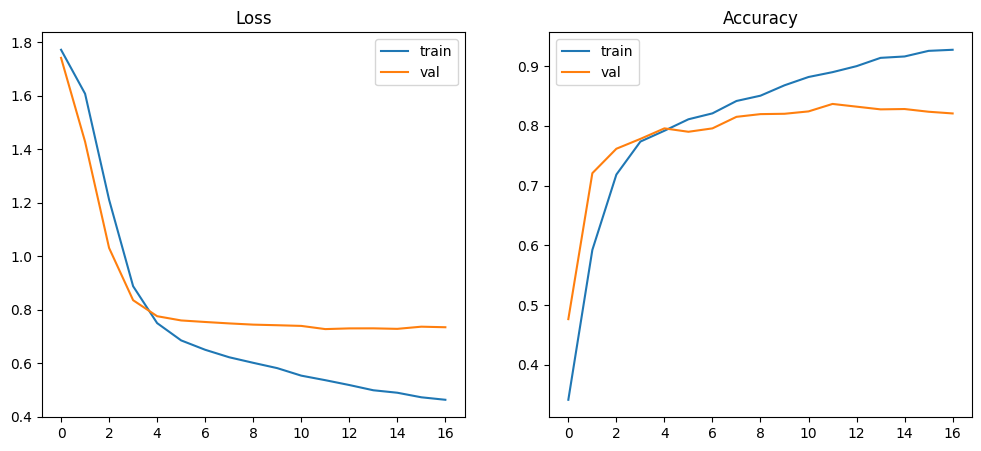

In [16]:
# CELL 14 — Training Curves
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(hist.history["loss"], label="train")
plt.plot(hist.history["val_loss"], label="val")
plt.title("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(hist.history["accuracy"], label="train")
plt.plot(hist.history["val_accuracy"], label="val")
plt.title("Accuracy")
plt.legend()

plt.show()


===== WINDOW RESULTS =====
Window accuracy: 0.8972758229284904

Classification Report (Window)
              precision    recall  f1-score   support

           1       0.95      1.00      0.98       294
           2       0.93      0.90      0.92       294
           3       0.77      0.84      0.81       294
           4       0.80      0.79      0.79       294
           5       0.95      0.94      0.95       294
           6       1.00      0.90      0.95       292

    accuracy                           0.90      1762
   macro avg       0.90      0.90      0.90      1762
weighted avg       0.90      0.90      0.90      1762



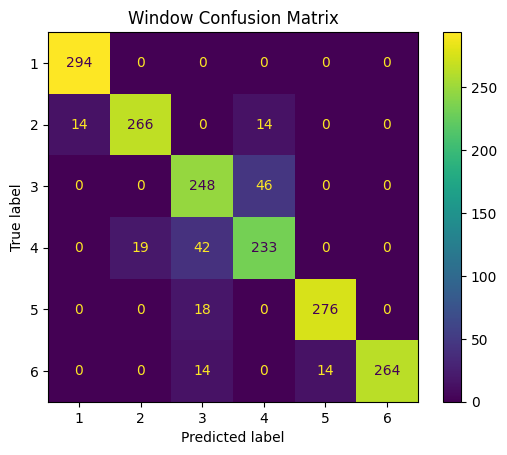

In [17]:
# CELL 15 — Window Level Evaluation
# =========================================
# WINDOW LEVEL EVALUATION
# =========================================

probs = model.predict(X_test, verbose=0)

y_pred = np.argmax(probs, axis=1)
y_true = np.argmax(y_test, axis=1)

window_acc = np.mean(y_pred == y_true)

print("\n===== WINDOW RESULTS =====")
print("Window accuracy:", window_acc)

print("\nClassification Report (Window)")

print(classification_report(
    y_true,
    y_pred,
    labels=np.arange(len(POSTURES)),
    target_names=POSTURES,
    zero_division=0
))

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=np.arange(len(POSTURES))
)

ConfusionMatrixDisplay(cm, display_labels=POSTURES).plot()

plt.title("Window Confusion Matrix")
plt.show()


===== TRIAL RESULTS =====
Trial accuracy: 0.8968253968253969

Classification Report (Trial)
              precision    recall  f1-score   support

           1       0.95      1.00      0.98        21
           2       0.95      0.90      0.93        21
           3       0.75      0.86      0.80        21
           4       0.81      0.81      0.81        21
           5       0.95      0.90      0.93        21
           6       1.00      0.90      0.95        21

    accuracy                           0.90       126
   macro avg       0.90      0.90      0.90       126
weighted avg       0.90      0.90      0.90       126



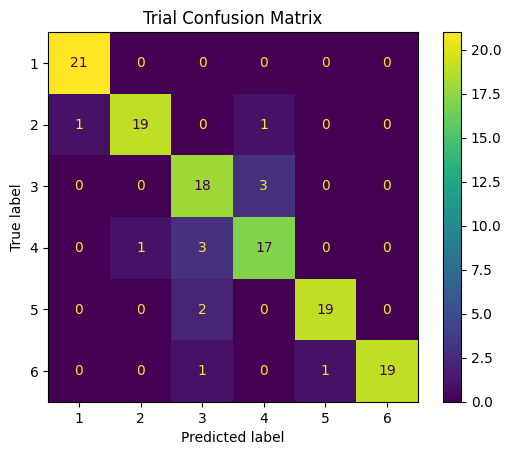

In [18]:
# CELL 16 — Trial Level Evaluation
from collections import defaultdict

# =========================================
# TRIAL LEVEL EVALUATION
# =========================================

trial_probs = defaultdict(list)
trial_true = {}

test_subjects = subj_all[test_mask]
test_trials = trial_all[test_mask]

for p,true,s,t in zip(probs, y_true, test_subjects, test_trials):

    key = (s,t)   # subject + trial

    trial_probs[key].append(p)
    trial_true[key] = true

trial_pred = []
trial_true_list = []
trial_subjects = []

for k in trial_probs:

    w = np.array(trial_probs[k])

    summed = np.sum(np.log(w + 1e-8), axis=0)

    pred = np.argmax(summed)

    trial_pred.append(pred)
    trial_true_list.append(trial_true[k])
    trial_subjects.append(k[0])   # store subject id

trial_pred = np.array(trial_pred)
trial_true_list = np.array(trial_true_list)
trial_subjects = np.array(trial_subjects)

trial_acc = np.mean(trial_pred == trial_true_list)

print("\n===== TRIAL RESULTS =====")
print("Trial accuracy:", trial_acc)

print("\nClassification Report (Trial)")

print(classification_report(
    trial_true_list,
    trial_pred,
    labels=np.arange(len(POSTURES)),
    target_names=POSTURES,
    zero_division=0
))

cm = confusion_matrix(
    trial_true_list,
    trial_pred,
    labels=np.arange(len(POSTURES))
)

ConfusionMatrixDisplay(cm, display_labels=POSTURES).plot()

plt.title("Trial Confusion Matrix")
plt.show()


===== SUBJECT-POSTURE RESULTS =====
Subject/Posture accuracy: 0.9285714285714286

Classification Report (Subject/Posture)
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         7
           2       1.00      1.00      1.00         7
           3       0.75      0.86      0.80         7
           4       0.86      0.86      0.86         7
           5       1.00      0.86      0.92         7
           6       1.00      1.00      1.00         7

    accuracy                           0.93        42
   macro avg       0.93      0.93      0.93        42
weighted avg       0.93      0.93      0.93        42



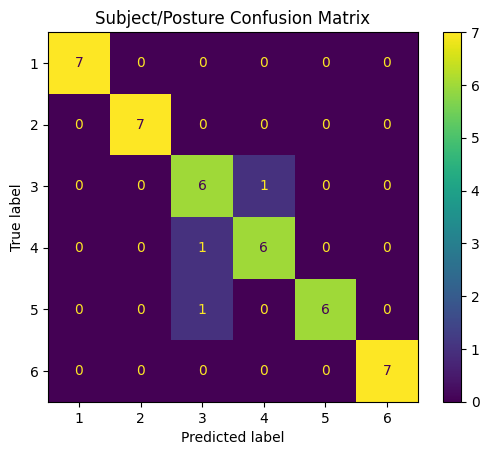

In [19]:
# CELL 17 — Subject-Posture Level Evaluation
# =========================================
# SUBJECT-POSTURE LEVEL EVALUATION
# =========================================

subject_posture_votes = defaultdict(list)
subject_posture_true = {}

for pred,true,s in zip(trial_pred, trial_true_list, trial_subjects):

    key = (s,true)   # subject + posture

    subject_posture_votes[key].append(pred)
    subject_posture_true[key] = true

subject_pred = []
subject_true_list = []

for k in subject_posture_votes:

    votes = np.array(subject_posture_votes[k])

    pred = np.bincount(votes).argmax()

    subject_pred.append(pred)
    subject_true_list.append(subject_posture_true[k])

subject_pred = np.array(subject_pred)
subject_true_list = np.array(subject_true_list)

subject_acc = np.mean(subject_pred == subject_true_list)

print("\n===== SUBJECT-POSTURE RESULTS =====")
print("Subject/Posture accuracy:", subject_acc)

print("\nClassification Report (Subject/Posture)")

print(classification_report(
    subject_true_list,
    subject_pred,
    labels=np.arange(len(POSTURES)),
    target_names=POSTURES,
    zero_division=0
))

cm = confusion_matrix(
    subject_true_list,
    subject_pred,
    labels=np.arange(len(POSTURES))
)

ConfusionMatrixDisplay(cm, display_labels=POSTURES).plot()

plt.title("Subject/Posture Confusion Matrix")
plt.show()